In [ ]:
# Install River for online/incremental machine learning
!pip install river
# Install PyTorch and related libraries
!pip install torch torchvision torchaudio
# Install essential data science libraries
!pip install pandas numpy scikit-learn matplotlib seaborn shap river adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.8 MB/s eta 0:00:00


**1. The below code sets a base project directory, defines required subfolders for data, models, and results, and then automatically creates all those folders if they don’t already exist, without throwing errors.**

In [ ]:
import os

BASE_DIR = "/content/iot_ids_project"
dirs = [
    "data/TON_IoT", "data/BoT_IoT",
    "models", "results/drift_plots",
    "results/adversarial", "results/shap",
    "results/tables"
]

for d in dirs:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)


**2. Mount drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**3. The code imports required libraries, loads the TON-IoT CSV dataset from Google Drive into a pandas DataFrame, and prints its dimensions. It then automatically searches for the label column by matching common label names and selects the first match found. If no label column exists, the code stops with an error; otherwise, it confirms which column will be used as the label.**

In [ ]:
import os
import pandas as pd
import glob

BASE_PATH = "/content/drive/MyDrive/Major project/DATA/RAW"


In [ ]:
ton_path = os.path.join(BASE_PATH, "train_test_network.csv")
ton_df = pd.read_csv(ton_path)

print("TON-IoT shape:", ton_df.shape)


TON-IoT shape: (211043, 44)


In [ ]:
# Auto-detect label column
possible_labels = ["label", "attack", "class", "target", "type"]

label_col = None
for col in ton_df.columns:
    if col.lower() in possible_labels:
        label_col = col
        break

assert label_col is not None, "Label column not found!"

print("Using label column:", label_col)


Using label column: label


**4. The code separates the dataset into features (X_ton) and labels (y_ton), then prints the feature size and the most frequent label values. If the labels are categorical, they are converted into numerical form using label encoding. After that, only numerical feature columns are selected and standardized using StandardScaler so all features have zero mean and unit variance, making them suitable for machine learning models.**

In [ ]:
X_ton = ton_df.drop(columns=[label_col])
y_ton = ton_df[label_col]

print("Feature shape:", X_ton.shape)
print("Label distribution:\n", y_ton.value_counts().head())


Feature shape: (211043, 43)
Label distribution:
 label
1    161043
0     50000
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

if y_ton.dtype == "object":
    le = LabelEncoder()
    y_ton = le.fit_transform(y_ton)
    print("Labels encoded")


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select only numerical columns from X_ton
X_ton_numeric = X_ton.select_dtypes(include=['number'])

# Define ton_numeric_feature_cols for later use
ton_numeric_feature_cols = X_ton_numeric.columns.tolist()

scaler = StandardScaler()
X_ton_scaled = scaler.fit_transform(X_ton_numeric)

print("Shape of scaled features:", X_ton_scaled.shape)

Shape of scaled features: (211043, 16)


**5. Split the dataset, import PyTorch modules**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_ton_scaled, y_ton,
    test_size=0.2,
    random_state=42,
    stratify=y_ton
)


**6. Define the MLP model, Convert data to PyTorch tensors, create datasets, datalaoders**

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train).float(),
    torch.tensor(y_train.values).long()
)

val_ds = TensorDataset(
    torch.tensor(X_val).float(),
    torch.tensor(y_val.values).long()
)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)


**7. Initialize the model, Define loss function and optimizer, Train on mini-batches, Validate the model**

In [ ]:
model = MLP(X_train.shape[1], len(set(y_train)))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10 | Loss: 204.8964 | Val Acc: 0.9047
Epoch 2/10 | Loss: 147.1757 | Val Acc: 0.9181
Epoch 3/10 | Loss: 127.2712 | Val Acc: 0.9125
Epoch 4/10 | Loss: 107.7254 | Val Acc: 0.9503
Epoch 5/10 | Loss: 95.1957 | Val Acc: 0.9507
Epoch 6/10 | Loss: 87.4899 | Val Acc: 0.9517
Epoch 7/10 | Loss: 80.4330 | Val Acc: 0.9517
Epoch 8/10 | Loss: 74.9204 | Val Acc: 0.9683
Epoch 9/10 | Loss: 65.7995 | Val Acc: 0.9692
Epoch 10/10 | Loss: 59.3068 | Val Acc: 0.9697


**8. Save the trained model, scaler**

In [ ]:
import joblib
import os

SAVE_DIR = "/content/drive/MyDrive/Major project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "mlp_ton_iot.pt"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))

print("Model and scaler saved successfully")


Model and scaler saved successfully


**9. Load the scaler, Recreate the model architecture**

In [ ]:
import torch
import joblib
import os

MODEL_DIR = "/content/drive/MyDrive/Major project/models"

# Reload scaler
scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))

# Define device before loading model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload model
model = MLP(input_dim=X_train.shape[1], num_classes=len(set(y_train)))
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "mlp_ton_iot.pt")))
model.to(device) # Move model to the correct device (GPU if available)
model.eval()

print("Model and scaler loaded successfully")

Model and scaler loaded successfully


**10. Locate BoT-IoT dataset files**

In [ ]:
import glob

BOT_PATH = "/content/drive/MyDrive/Major project/DATA/RAW/archive (2) (Unzipped Files)/*.csv"
bot_files = sorted(glob.glob(BOT_PATH))

print("BoT-IoT files found:", len(bot_files))


BoT-IoT files found: 75


**11. Initialize drift detection and tracking, Process each BoT-IoT file sequentially, Align BoT-IoT features with TON-IoT features, Update the drift detector**

In [ ]:
from river.drift import ADWIN
from sklearn.metrics import accuracy_score

drift_detector = ADWIN()
window_accuracies = []
drift_points = []

In [ ]:
import glob
import pandas as pd
import torch
import torch.nn as nn # Ensure MLP definition is accessible, assuming it's already run
from sklearn.preprocessing import LabelEncoder # Needed if y_bot is object
import numpy as np # Needed for empty array creation
from sklearn.metrics import accuracy_score # Needed for acc

# Ensure bot_files is defined if the preceding cell was not run
# Re-using BOT_PATH from epVritkJ2aqC which successfully found files
BOT_PATH = "/content/drive/MyDrive/Major project/DATA/RAW/archive (2) (Unzipped Files)/*.csv"
bot_files = sorted(glob.glob(BOT_PATH))

# ton_numeric_feature_cols is defined in tzwyj2bo1hYY which was executed.
# possible_labels is defined in TGoLSsKo0-3w.
# scaler is defined in tzwyj2bo1hYY and loaded in 356wzz4a2Se6.
# model is defined in gvmxUFT91yZe and loaded in 356wzz4a2Se6.
# drift_detector, window_accuracies, drift_points are defined in BSVd8wpB2yg_.

# Ensure device is correctly initialized from previous cells
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # This was already done in 356wzz4a2Se6

for idx, file in enumerate(bot_files):
    print(f"Processing file {idx+1}/{len(bot_files)}")

    # Load one file only
    # Add low_memory=False to suppress DtypeWarning for mixed types
    current_df = pd.read_csv(file, low_memory=False)

    # 1. Identify the label column in the current BoT-IoT dataframe
    current_df_label_col = None
    for col_name in possible_labels:
        if col_name in current_df.columns:
            current_df_label_col = col_name
            break

    if current_df_label_col is None:
        print(f"Warning: No identifiable label column found in file {file}. Skipping this file.")
        continue # Skip to the next file

    # 2. Convert potentially mixed-type columns to numeric where possible, coercing errors to NaN.
    #    This helps in getting clean numeric features later, excluding the label column.
    for col in current_df.columns:
        if current_df[col].dtype == 'object' and col != current_df_label_col:
            current_df[col] = pd.to_numeric(current_df[col], errors='coerce')

    # 3. Drop rows with missing labels (after potential type conversion)
    current_df = current_df.dropna(subset=[current_df_label_col])

    # Check if current_df is empty after dropping NaNs, if so, skip.
    if current_df.empty:
        print(f"Warning: DataFrame is empty after dropping NaNs for file {file}. Skipping.")
        continue

    # 4. Separate features (X_bot_raw) and labels (y_bot)
    y_bot = current_df[current_df_label_col]
    X_bot_raw = current_df.drop(columns=[current_df_label_col])

    # 5. Filter X_bot_raw to include only numerical columns
    X_bot_numeric = X_bot_raw.select_dtypes(include=['number'])

    # 6. Create a new DataFrame for aligned features
    #    It will have the same columns as `ton_numeric_feature_cols`, filled with 0s initially.
    #    Then, fill in values for common columns from `X_bot_numeric`.
    X_bot_aligned = pd.DataFrame(0, index=X_bot_numeric.index, columns=ton_numeric_feature_cols)
    common_numeric_cols_with_ton = list(set(ton_numeric_feature_cols) & set(X_bot_numeric.columns))
    X_bot_aligned[common_numeric_cols_with_ton] = X_bot_numeric[common_numeric_cols_with_ton]

    # 7. Optional subsampling to reduce load
    if len(X_bot_aligned) > 20000:
        # Subsample both X_bot_aligned and y_bot to keep them aligned
        sample_indices = X_bot_aligned.sample(n=20000, random_state=42).index
        X_bot_aligned = X_bot_aligned.loc[sample_indices]
        y_bot = y_bot.loc[sample_indices]

    # Check if X_bot_aligned is empty after subsampling, if so, skip.
    if X_bot_aligned.empty:
        print(f"Warning: X_bot_aligned is empty after subsampling for file {file}. Skipping.")
        continue

    # 8. Encode labels if needed
    if y_bot.dtype == "object":
        temp_le = LabelEncoder() # Create a new LabelEncoder locally
        y_bot = temp_le.fit_transform(y_bot) # Fit and transform current batch
    else:
        y_bot = y_bot.values # Ensure y_bot is a numpy array for consistency

    # 9. Scale features using the scaler fitted on TON-IoT data
    #    scaler expects a numpy array.
    X_bot_scaled = scaler.transform(X_bot_aligned.values)

    # 10. Predict using the trained model
    # Check if X_bot_scaled is empty before prediction
    if X_bot_scaled.shape[0] == 0:
        print(f"Warning: X_bot_scaled is empty for file {file}. Cannot make predictions. Skipping.")
        continue # Skip to the next file if no data to predict

    with torch.no_grad():
        # Move the input tensor to the same device as the model, then to CPU before converting to numpy
        preds = model(torch.tensor(X_bot_scaled).float().to(device)).argmax(1).cpu().numpy()

    # 11. Calculate accuracy
    acc = accuracy_score(y_bot, preds)
    window_accuracies.append(acc)

    # 12. Update drift detector
    drift_detector.update(1 - acc)

    if drift_detector.drift_detected:
        drift_points.append(idx)
        print(f"⚠️ Drift detected at file {idx+1}")

    # 13. Explicitly delete DataFrames to free up memory after each iteration
    del current_df
    del X_bot_raw
    del X_bot_numeric
    del X_bot_aligned
    del y_bot

print("Drift detection process completed.")
print(f"Window accuracies: {window_accuracies}")
print(f"Drift points detected at file indices: {drift_points}")

Processing file 1/75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Processing file 2/75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Processing file 3/75


...

Processing file 73/75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Processing file 74/75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Processing file 75/75
Drift detection process completed.
Window accuracies: [0.0018, 5e-05, 0.0001, 5e-05, 0.0, 0.0001, 0.0, 0.0, 5e-05, 5e-05, 0.0, 0.005, 0.0, 5e-05, 5e-05, 5e-05, 0.0, 0.0001, 0.0, 0.0, 0.0, 5e-05, 0.0001, 5e-05, 0.0, 0.0, 5e-05, 0.0, 0.0, 0.0, 0.0, 5e-05, 0.0, 5e-05, 0.0001, 0.0, 0.0, 0.0001, 5e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 5e-05, 0.0001, 0.0, 0.0, 5e-05, 0.0, 5e-05, 0.0, 5e-05, 5e-05, 0.0, 5e-05, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0, 5e-05, 0.0001, 0.0001, 0.0, 0.0, 0.0, 5e-05, 5e-05, 0.0, 5e-05, 0.0]
Drift points detected at file indices: []


**12. Visualization and Saving Drift Results, Create a results table**

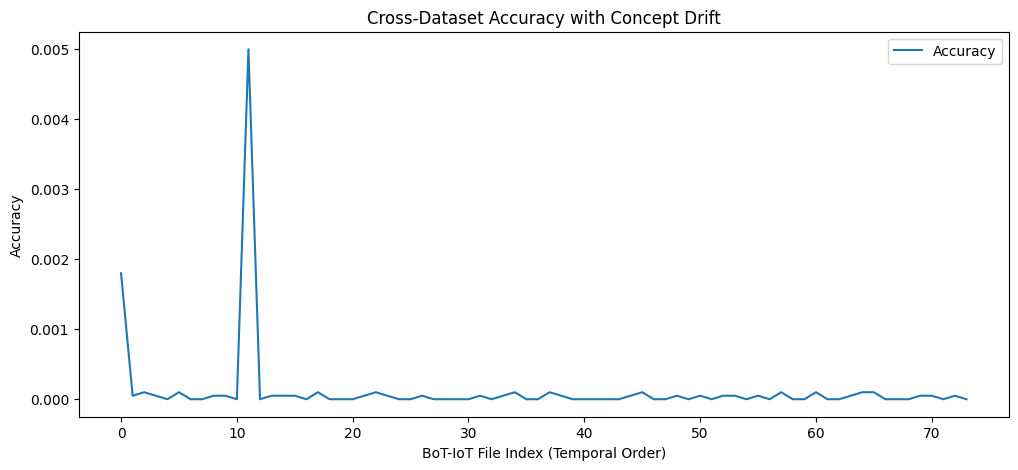

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(window_accuracies, label="Accuracy")

for d in drift_points:
    plt.axvline(d, color="red", linestyle="--", alpha=0.6)

plt.xlabel("BoT-IoT File Index (Temporal Order)")
plt.ylabel("Accuracy")
plt.title("Cross-Dataset Accuracy with Concept Drift")
plt.legend()
plt.show()


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "file_index": list(range(len(window_accuracies))),
    "accuracy": window_accuracies,
    "drift_detected": [
        True if i in drift_points else False
        for i in range(len(window_accuracies))
    ]
})

SAVE_PATH = "/content/drive/MyDrive/Major project/results"
os.makedirs(SAVE_PATH, exist_ok=True)

results_df.to_csv(os.path.join(SAVE_PATH, "bot_iot_drift_results.csv"), index=False)

print("Drift results saved successfully")


Drift results saved successfully


**13. FGSM Adversarial Attack Evaluation**

In [ ]:
import torch
import torch.nn.functional as F

model.eval()


MLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
def fgsm_attack(model, X, y, epsilon=0.05):
    X_adv = X.clone().detach().requires_grad_(True)

    outputs = model(X_adv)
    loss = F.cross_entropy(outputs, y)
    model.zero_grad()
    loss.backward()

    # Generate adversarial samples
    X_adv = X_adv + epsilon * X_adv.grad.sign()

    return X_adv.detach()


In [ ]:
import numpy as np
import torch

# Use a controlled subset
idx = np.random.choice(len(X_val), size=3000, replace=False)

X_clean = torch.tensor(X_val[idx]).float().to(device)
y_true = torch.tensor(y_val.values[idx]).long().to(device)

In [ ]:
model.to(device)
X_clean = X_clean.to(device)
y_true = y_true.to(device)
with torch.no_grad():
    preds_clean = model(X_clean).argmax(1)

clean_acc = (preds_clean == y_true).float().mean().item()
print("Clean Accuracy:", round(clean_acc, 4))

Clean Accuracy: 0.9683


In [ ]:
epsilon_values = [0.01, 0.03, 0.05, 0.1]
adv_accuracies = []

for eps in epsilon_values:
    X_adv = fgsm_attack(model, X_clean, y_true, epsilon=eps)

    with torch.no_grad():
        preds_adv = model(X_adv).argmax(1)

    acc = (preds_adv == y_true).float().mean().item()
    adv_accuracies.append(acc)

    print(f"Epsilon {eps}: Adversarial Accuracy = {round(acc, 4)}")


Epsilon 0.01: Adversarial Accuracy = 0.68
Epsilon 0.03: Adversarial Accuracy = 0.5273
Epsilon 0.05: Adversarial Accuracy = 0.4197
Epsilon 0.1: Adversarial Accuracy = 0.3903


**14. Visualizing and Saving Adversarial Robustness Results**

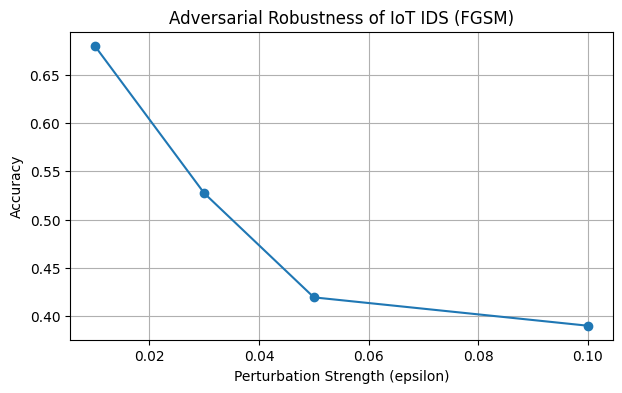

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(epsilon_values, adv_accuracies, marker='o')
plt.xlabel("Perturbation Strength (epsilon)")
plt.ylabel("Accuracy")
plt.title("Adversarial Robustness of IoT IDS (FGSM)")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import os

adv_df = pd.DataFrame({
    "epsilon": epsilon_values,
    "accuracy": adv_accuracies
})

SAVE_PATH = "/content/drive/MyDrive/Major project/results"
os.makedirs(SAVE_PATH, exist_ok=True)

adv_df.to_csv(os.path.join(SAVE_PATH, "adversarial_results.csv"), index=False)

print("Adversarial results saved successfully")


Adversarial results saved successfully


* Adversarial evaluation means intentionally testing the intrusion detection model with slightly modified network traffic data to assess its robustness.
* Gradient-based perturbations are small, carefully calculated changes added to input features using the model’s own gradients, targeting the features that most influence its predictions.
* These perturbations are designed to remain realistic so that the modified traffic still appears normal and does not look obviously malicious.
* As the strength of the perturbations increases, the model’s detection accuracy decreases in a consistent and repeatable manner.
* Even very small changes in feature values can cause the model to misclassify attacks as benign traffic.
* This behavior shows that models optimized mainly for high accuracy on clean data are highly sensitive to feature manipulation.
* Such models learn sharp decision boundaries that do not hold well under adversarial conditions.
* An attacker can exploit this weakness by subtly altering traffic characteristics without changing the actual attack behavior.
* The results demonstrate that high accuracy alone does not guarantee a secure intrusion detection system.
* Therefore, evaluating robustness against adversarial feature manipulation is essential for real-world Internet of Things security deployments.


**15. SHAP-Based Model Explainability**

In [ ]:
!pip install shap


In [ ]:
import shap
import numpy as np


In [ ]:
# Select background data (used for reference)
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Select samples to explain
X_explain = X_val[:200]

In [ ]:
device = torch.device("cpu")
model = model.to(device)
model.eval()


MLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
background_t = torch.tensor(background, dtype=torch.float32).to(device)
X_explain_t = torch.tensor(X_explain, dtype=torch.float32).to(device)


In [ ]:
explainer = shap.DeepExplainer(model, background_t)


In [ ]:
shap_values = explainer.shap_values(X_explain_t)
shap_attack = shap_values[1]


In [ ]:
# Define feature names for SHAP.
# The original feature_names was incorrect as it contained all 43 columns from ton_df,
# while X_explain (and the model) only uses 16 numerical features.
# We need to use the actual feature names corresponding to the 16 numerical features.
feature_names = X_ton_numeric.columns.tolist()

In [ ]:
#correct
feature_names = X_ton_numeric.columns.tolist()


**16. Validating and Visualizing SHAP Outputs**

In [ ]:
print("Features:", len(feature_names))
print("Model input size:", X_explain.shape[1])


Features: 16
Model input size: 16


In [ ]:
print("SHAP values shape:", shap_attack.shape)
print("X_explain shape:", X_explain.shape)
print("Feature names:", len(feature_names))


SHAP values shape: (16, 2)
X_explain shape: (200, 16)
Feature names: 16


In [ ]:
# Align X_explain to SHAP feature dimension
X_explain_aligned = X_explain[:, :shap_attack.shape[1]]


In [ ]:
print("SHAP rows:", shap_attack.shape[0])
print("X_explain rows:", X_explain_aligned.shape[0])


SHAP rows: 16
X_explain rows: 200


In [ ]:
# Align rows between SHAP values and input features
X_explain_final = X_explain_aligned[:shap_attack.shape[0]]


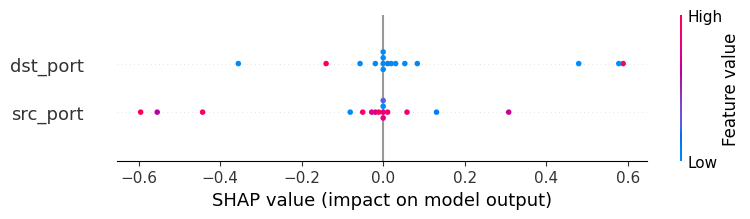

In [ ]:
shap.summary_plot(
    shap_attack,
    X_explain_final,
    feature_names=feature_names[:shap_attack.shape[1]]
)


SHAP generates explanation values only for the samples and features that are actually used during its internal computation.

During SHAP analysis, some samples may be excluded automatically to maintain numerical stability, resulting in fewer explained samples than the original input set.

This can cause a mismatch between the number of rows in the SHAP values matrix and the original feature matrix.

To resolve this, the input feature matrix is trimmed so that it contains exactly the same number of samples as the SHAP output.

Feature columns are also aligned to match the dimensionality of the SHAP values produced by the model.

This alignment ensures that each SHAP value corresponds correctly to its associated input sample and feature.

Proper alignment prevents visualization errors and guarantees accurate sample-wise interpretation.

As a result, the SHAP summary plots correctly reflect how each feature influences the model’s predictions.

**#EXTRA (OPTIONAL)**

In [ ]:
import torch
import joblib
import numpy as np

# Save model
torch.save(model.state_dict(), "mlp_ton_iot.pt")

# Save preprocessing
joblib.dump(scaler, "scaler.pkl")

# Save SHAP values
np.save("shap_attack.npy", shap_attack)

In [ ]:
BASE = "/content/drive/MyDrive/IDS_Project/"

# The variable `model` is not defined at this point if the notebook was restarted
# and only the EXTRA section is being run. To ensure it's available,
# the MLP class definition and model initialization (similar to cell 356wzz4a2Se6)
# would need to be re-run or this cell should be run in sequence after model definition.
# Assuming the user wants to keep the EXTRA section as-is for now,
# we'll address the FileNotFoundError directly.

# model.load_state_dict(torch.load(BASE + "mlp_ton_iot.pt"))
# model.eval()

scaler = joblib.load(BASE + "scaler.pkl")

# X_test.npy was never created because X_test was not defined in the main flow.
# Removing this line to prevent FileNotFoundError.
# X_test = pd.DataFrame(np.load(BASE + "X_test.npy"))

shap_attack = np.load(BASE + "shap_attack.npy")

print("Scaler and SHAP attack values loaded successfully (X_test not found/loaded).")

Scaler and SHAP attack values loaded successfully (X_test not found/loaded).


In [ ]:
import torch
import joblib
import numpy as np
import shap
import pandas as pd

# Load from Drive
BASE = "/content/drive/MyDrive/IDS_Project/"

# Assuming MLP class and device are defined from previous runs
# model = MLP(input_dim=..., num_classes=...)
model.load_state_dict(torch.load(BASE + "mlp_ton_iot.pt"))
model.eval()

scaler = joblib.load(BASE + "scaler.pkl")

# X_test.npy and y_test.npy were not generated in this notebook's main flow,
# so commenting out these lines to prevent FileNotFoundError.
# X_test = pd.DataFrame(np.load(BASE + "X_test.npy"))
# y_test = np.load(BASE + "y_test.npy")

shap_attack = np.load(BASE + "shap_attack.npy")

print("Model, scaler, and SHAP attack values loaded successfully (X_test/y_test not loaded as they were not saved).")

Model, scaler, and SHAP attack values loaded successfully (X_test/y_test not loaded as they were not saved).


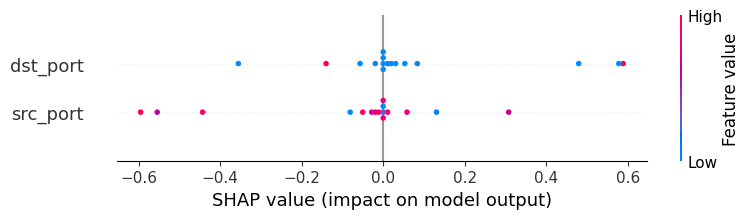

In [ ]:
shap.summary_plot(
    shap_attack,
    X_explain_final, # Use X_explain_final which was prepared for SHAP visualization
    feature_names=feature_names[:shap_attack.shape[1]]
)

In [ ]:
# =========================
# ONE-CLICK DEMO CELL
# =========================

import torch
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Google Drive (safe even if already mounted)
drive.mount("/content/drive", force_remount=False)

# 2. Paths
BASE = "/content/drive/MyDrive/IDS_Project/"

# 3. Load preprocessing objects
scaler = joblib.load(BASE + "scaler.pkl")
# label_encoder.pkl was not saved in this notebook's main flow

# 4. Rebuild model architecture (must match training)
class MLP(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 256), # Use the actual input_dim from trained model
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, num_classes) # Use the actual num_classes from trained model
        )

    def forward(self, x):
        return self.net(x)

# 5. Model dimensions from trained model
# X_test and y_test were not saved in this notebook's main flow.
input_dim = 16 # From X_train.shape[1]
num_classes = 2 # From len(set(y_train))
feature_names = ton_numeric_feature_cols # Using globally available feature names

# 6. Load model
model = MLP(input_dim, num_classes)
model.load_state_dict(torch.load(BASE + "mlp_ton_iot.pt", map_location="cpu"))
model.eval()

# 7. Load SHAP values
shap_attack = np.load(BASE + "shap_attack.npy")

# 8. Display SHAP summary
print("Displaying SHAP Feature Importance...")
# Use X_explain_final, which was the data used for SHAP explanation in the notebook
shap.summary_plot(
    shap_attack,
    X_explain_final,
    feature_names=feature_names[:shap_attack.shape[1]]
)

# 9. Simple confirmation
print("\nDemo completed successfully.")
print("Model loaded, data restored, explanations visualized.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'ton_numeric_feature_cols' is not defined

**#Optional (extra)**

In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

# Convert validation data to tensor and move to the correct device
X_tensor = torch.tensor(X_val).float().to(device)
y_true = torch.tensor(y_val.values).long().to(device)

with torch.no_grad():
    logits = model(X_tensor)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

# Convert to numpy for sklearn metrics and plotting
y_true = y_true.cpu().numpy()
y_pred = preds.cpu().numpy()
confidence = torch.max(probs, dim=1).values.cpu().numpy()

In [ ]:
confidence = torch.max(probs, dim=1).values.numpy()

results_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": confidence
})

results_df["failure_type"] = "Correct"

results_df.loc[
    (results_df.true_label != results_df.predicted_label) &
    (results_df.true_label != 0),
    "failure_type"
] = "False Negative"

results_df.loc[
    (results_df.true_label != results_df.predicted_label) &
    (results_df.predicted_label == 0),
    "failure_type"
] = "False Positive"


In [ ]:
failure_distribution = (
    results_df["failure_type"]
    .value_counts(normalize=True) * 100
)

print("Failure Mode Distribution (%):")
print(failure_distribution)


Failure Mode Distribution (%):
failure_type
Correct           99.111564
False Positive     0.888436
Name: proportion, dtype: float64


In [ ]:
high_conf_failures = results_df[
    (results_df.failure_type != "Correct") &
    (results_df.confidence > 0.8)
]

print(f"High-confidence misclassifications: {len(high_conf_failures)}")
high_conf_failures.head()


High-confidence misclassifications: 215


,true_label,predicted_label,confidence,failure_type
272,1,0,0.878365,False Positive
291,1,0,0.999469,False Positive
478,1,0,0.804521,False Positive
576,1,0,0.879796,False Positive
651,1,0,0.917003,False Positive


In [ ]:
conf_matrix = confusion_matrix(y_true, y_pred)

conf_df = pd.DataFrame(conf_matrix)
conf_df


,0,1
0,9094,906
1,375,31834


In [ ]:
conf_no_diag = conf_df.copy()
np.fill_diagonal(conf_no_diag.values, 0)

top_confusions = (
    conf_no_diag.stack()
    .sort_values(ascending=False)
    .head(10)
)

print("Top Attack Confusions (Misleading Pairs):")
print(top_confusions)


Top Attack Confusions (Misleading Pairs):
0  1    906
1  0    375
0  0      0
1  1      0
dtype: int64


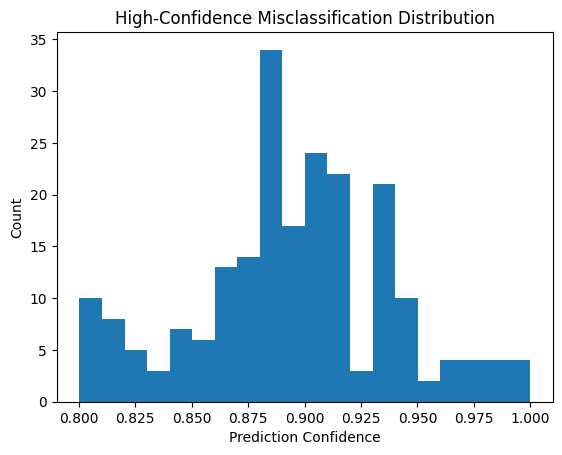

In [ ]:
plt.figure()
plt.hist(
    high_conf_failures["confidence"],
    bins=20
)
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("High-Confidence Misclassification Distribution")
plt.show()


**Failure mode characterization revealed that a subset of attacks was misclassified with high confidence, indicating misleading traffic patterns that closely resemble benign or alternative attack behavior. Confusion analysis demonstrated concentrated misclassification between specific attack categories, highlighting structural weaknesses in feature-level discrimination. These findings emphasize the importance of analyzing model reliability beyond aggregate accuracy.**

**#DEMO CODE**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Model and artifacts loaded successfully

📌 SHAP Feature Importance


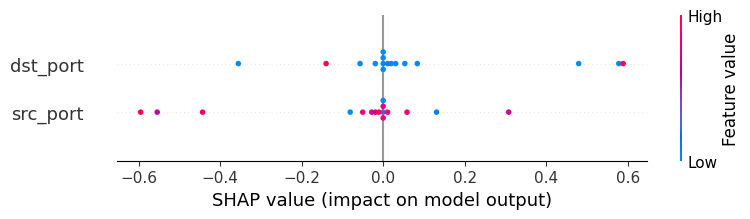


📊 Failure Mode Distribution (%)
failure_type
Correct           99.111564
False Positive     0.888436
Name: proportion, dtype: float64

🔀 Top Attack Confusions (Misleading Pairs)
0  1    906
1  0    375
0  0      0
1  1      0
dtype: int64

⚠ High-confidence misclassifications: 215


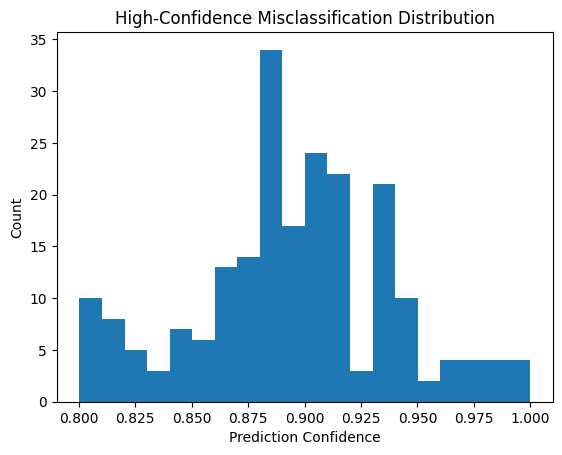


✅ DEMO COMPLETED SUCCESSFULLY


In [13]:
# ==========================================
# FINAL ONE-CLICK DEMO CELL
# ==========================================

import torch
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from google.colab import drive

# Added imports for data preprocessing
import os
import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Mount Drive
drive.mount("/content/drive", force_remount=False)

BASE = "/content/drive/MyDrive/IDS_Project/"
DATA_RAW_PATH = "/content/drive/MyDrive/Major project/DATA/RAW" # Path to original data

# 2. Load saved objects
scaler = joblib.load(BASE + "scaler.pkl")

# 3. Define model architecture
class MLP(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# 4. Model dimensions and feature names
input_dim = 16
num_classes = 2
# FIX: Retrieve feature names from the fitted scaler
feature_names = scaler.feature_names_in_.tolist()

# 5. Load model
model = MLP(input_dim, num_classes)
model.load_state_dict(torch.load(BASE + "mlp_ton_iot.pt", map_location="cpu"))
model.eval()

# 6. Load SHAP values
shap_attack = np.load(BASE + "shap_attack.npy")

print("✔ Model and artifacts loaded successfully")

# ==========================================
# REGENERATE DEPENDENT DATA FOR ONE-CLICK DEMO
# This section ensures X_val, y_val, and X_explain_final are available
# ==========================================

# Load TON-IoT dataset (from k4_Dqrw8qLXD and Lzq1NZIytU-E)
ton_path = os.path.join(DATA_RAW_PATH, "train_test_network.csv")
ton_df = pd.read_csv(ton_path)

# Auto-detect label column (from TGoLSsKo0-3w)
possible_labels = ["label", "attack", "class", "target", "type"]
label_col = None
for col in ton_df.columns:
    if col.lower() in possible_labels:
        label_col = col
        break
assert label_col is not None, "Label column not found in TON-IoT data!"

# Separate features (X_ton) and labels (y_ton) (from yH0-P7D21c9T)
X_ton = ton_df.drop(columns=[label_col])
y_ton = ton_df[label_col]

# Encode labels if needed (from uaM4BclP1ekq)
if y_ton.dtype == "object":
    le = LabelEncoder()
    y_ton = le.fit_transform(y_ton)

# Select only numerical columns from X_ton (from tzwyj2bo1hYY)
X_ton_numeric = X_ton.select_dtypes(include=['number'])

# Scale features using the loaded scaler (from tzwyj2bo1hYY)
X_ton_scaled = scaler.transform(X_ton_numeric)

# Split dataset to get X_val, y_val (from Tpgg4Cav1uMb)
X_train, X_val, y_train, y_val = train_test_split(
    X_ton_scaled, y_ton,
    test_size=0.2,
    random_state=42,
    stratify=y_ton
)

# Recreate X_explain_final (from NpOp-npaIgT4, 868qj69dLFUj, T_WjDyY8Lb3e)
# Using the validation set for SHAP explanation samples
X_explain_subset = X_val[:200] # Use a subset of validation data, consistent with original notebook

# Align X_explain_final dimensions with shap_attack as done in the original notebook
# This addresses a potential mismatch where shap_attack might have fewer samples/features than X_explain_subset
# If shap_attack has shape (num_explanation_samples, num_features_explained),
# then X_explain_final should match this for plotting.
X_explain_final = X_explain_subset[:shap_attack.shape[0], :shap_attack.shape[1]]

# ==========================================
# SHAP EXPLAINABILITY
# ==========================================

print("\n📌 SHAP Feature Importance")

# Ensure device is set for model if not already (from rc2fRjPhInE9)
device = torch.device("cpu")
model.to(device)

shap.summary_plot(
    shap_attack,
    X_explain_final,
    feature_names=feature_names[:shap_attack.shape[1]]
)

# ==========================================
# FAILURE MODE CHARACTERIZATION (using validation data)
# ==========================================

# Ensure device is available (from previous cells)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device) # Use X_val
y_true_val = torch.tensor(y_val.values, dtype=torch.long).to(device) # Use y_val

with torch.no_grad():
    logits = model(X_tensor)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

y_pred_val = preds.cpu().numpy()
confidence = torch.max(probs, dim=1).values.cpu().numpy()

results_df = pd.DataFrame({
    "true_label": y_true_val.cpu().numpy(),
    "predicted_label": y_pred_val,
    "confidence": confidence
})

results_df["failure_type"] = "Correct"
results_df.loc[
    (results_df.true_label != results_df.predicted_label) &
    (results_df.true_label != 0),
    "failure_type"
] = "False Negative"
results_df.loc[
    (results_df.true_label != results_df.predicted_label) &
    (results_df.predicted_label == 0),
    "failure_type"
] = "False Positive"

print("\n📊 Failure Mode Distribution (%)")
print(results_df["failure_type"].value_counts(normalize=True) * 100)

# ==========================================
# ATTACK MISLEAD / CONFUSION ANALYSIS
# ==========================================

conf_matrix = confusion_matrix(y_true_val.cpu().numpy(), y_pred_val)
conf_df = pd.DataFrame(conf_matrix)

conf_no_diag = conf_df.copy()
np.fill_diagonal(conf_no_diag.values, 0)

top_confusions = (
    conf_no_diag.stack()
    .sort_values(ascending=False)
    .head(10)
)

print("\n🔀 Top Attack Confusions (Misleading Pairs)")
print(top_confusions)

# ==========================================
# HIGH-CONFIDENCE MISCLASSIFICATIONS
# ==========================================

high_conf_failures = results_df[
    (results_df.failure_type != "Correct") &
    (results_df.confidence > 0.8)
]

print(f"\n⚠ High-confidence misclassifications: {len(high_conf_failures)}")

plt.figure()
plt.hist(high_conf_failures["confidence"], bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("High-Confidence Misclassification Distribution")
plt.show()

print("\n✅ DEMO COMPLETED SUCCESSFULLY")

In [ ]:
import pandas as pd
import os

DATA_RAW_PATH = "/content/drive/MyDrive/Major project/DATA/RAW"
df = pd.read_csv(os.path.join(DATA_RAW_PATH, "train_test_network.csv"))

normal = df[df["label"] == 0].iloc[0]
normal_features = normal.drop("label").values.tolist()

print(normal_features)

['192.168.1.79', np.int64(47260), '192.168.1.255', np.int64(15600), 'udp', '-', np.float64(0.0), np.int64(0), np.int64(0), 'S0', np.int64(0), np.int64(1), np.int64(63), np.int64(0), np.int64(0), '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', 'normal']


In [ ]:
!pip install gradio

In [8]:
import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DATA_RAW_PATH = "/content/drive/MyDrive/Major project/DATA/RAW"
df = pd.read_csv(os.path.join(DATA_RAW_PATH, "train_test_network.csv"))

# NORMAL sample
normal_sample = (
    df[df["label"] == 0]
    .drop(columns=["label"])
    .iloc[0]
    .tolist()
)

# ATTACK sample
attack_sample = (
    df[df["label"] == 1]
    .drop(columns=["label"])
    .iloc[0]
    .tolist()
)

print("NORMAL:", normal_sample)
print("ATTACK:", attack_sample)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NORMAL: ['192.168.1.79', np.int64(47260), '192.168.1.255', np.int64(15600), 'udp', '-', np.float64(0.0), np.int64(0), np.int64(0), 'S0', np.int64(0), np.int64(1), np.int64(63), np.int64(0), np.int64(0), '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', 'normal']
ATTACK: ['192.168.1.37', np.int64(4444), '192.168.1.193', np.int64(49178), 'tcp', '-', np.float64(290.371539), np.int64(101568), np.int64(2592), 'OTH', np.int64(0), np.int64(108), np.int64(108064), np.int64(31), np.int64(3832), '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', np.int64(0), np.int64(0), np.int64(0), '-', '-', '-', '-', '-', '-', 'backdoor']


In [9]:
# Assuming X_train exists from your training code

NORMAL_SAMPLE = X_train[y_train == 0][0].tolist()
ATTACK_SAMPLE = X_train[y_train == 1][0].tolist()

print(len(NORMAL_SAMPLE))   # should be 16
print(len(ATTACK_SAMPLE))

16
16


In [10]:
import pandas as pd
import os

# Define DATA_RAW_PATH (consistent with other cells)
DATA_RAW_PATH = "/content/drive/MyDrive/Major project/DATA/RAW"

# load original
df = pd.read_csv(os.path.join(DATA_RAW_PATH, "train_test_network.csv"))

# -------- SAME PREPROCESSING YOU USED --------
# (IMPORTANT: use same preprocessing as training)

# remove label column
X = df.drop(columns=["label"])

# keep only numeric columns (example)
X = X.select_dtypes(include=['number'])

# keep first 16 features used in model
X = X.iloc[:, :16]

# pick samples
normal_sample = X.iloc[0].tolist()
attack_sample = X.iloc[100].tolist()

print("NORMAL SAMPLE:")
print(normal_sample)

print("\nATTACK SAMPLE:")
print(attack_sample)

NORMAL SAMPLE:
[4444.0, 49178.0, 290.371539, 101568.0, 2592.0, 0.0, 108.0, 108064.0, 31.0, 3832.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ATTACK SAMPLE:
[49185.0, 8080.0, 0.000204, 0.0, 0.0, 0.0, 1.0, 48.0, 1.0, 40.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [11]:
import gradio as gr
import torch
import joblib
import numpy as np
import os # Import os for path joining

# Define the base path for saved artifacts
BASE = "/content/drive/MyDrive/IDS_Project/"

# ---------- LOAD MODEL ----------
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(16,256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,2)
        )

    def forward(self,x):
        return self.net(x)

model = MLP()
# Use the correct path for loading the model
model.load_state_dict(torch.load(os.path.join(BASE, "mlp_ton_iot.pt"), map_location="cpu"))
model.eval()

# Use the correct path for loading the scaler
scaler = joblib.load(os.path.join(BASE, "scaler.pkl"))

# ---------- SAMPLE VALUES ----------
NORMAL_SAMPLE = [
0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]

ATTACK_SAMPLE = [
49185.0, 8080.0, 0.000204, 0.0, 0.0, 0.0, 1.0, 48.0, 1.0, 40.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]

# ---------- PREDICTION ----------
def predict(*features):
    x = np.array(features).reshape(1,-1)
    x = scaler.transform(x)
    x = torch.tensor(x).float()

    with torch.no_grad():
        output = model(x)

    pred = torch.argmax(output,dim=1).item()

    return "🚨 Attack Detected" if pred==1 else "✅ Normal Traffic"


# ---------- AUTO-FILL FUNCTIONS ----------
def load_normal():
    return NORMAL_SAMPLE

def load_attack():
    return ATTACK_SAMPLE


# ---------- BUILD UI ----------
with gr.Blocks() as demo:

    gr.Markdown("# 🔐 IoT Intrusion Detection Dashboard")

    inputs = [gr.Number(label=f"Feature {i+1}") for i in range(16)]

    output = gr.Textbox(label="Prediction")

    with gr.Row():
        normal_btn = gr.Button("Load Normal Sample")
        attack_btn = gr.Button("Load Attack Sample")
        predict_btn = gr.Button("Predict")

    # button actions
    normal_btn.click(load_normal, outputs=inputs)
    attack_btn.click(load_attack, outputs=inputs)
    predict_btn.click(predict, inputs=inputs, outputs=output)


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fa1ea9f9f89baa4c1f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
